<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#FFDD00;
           font-size:20px;
           font-family:Nexa;
           letter-spacing:0.5px">
        <p style="padding: 10px;
              color:black;">
            <b>Guide on handling Outliers</b>
        </p>
</div>
<div class="alert alert-block alert-info" style="font-size:14px; font-family:nexa;">
    Outliers are the different ones. In a distribution, if few of the datapoints have distinguishable characters compared to its counterparts, then it is termed as an outlier. Suppose in a dataset of students' performance, 98% of the students scored below 60 but only 2% scored above 85. In this example, these 2% students are outliers. 
</div>

<img src="https://www.writerscentre.com.au/wp-content/uploads/2020/05/diff.jpg" alt="min max formula" width="500" height="600">

<div class="alert alert-block alert-info" style="font-size:14px; font-family:nexa">
    In a machine learning problem, outliers create a loss of mess. Your accuracy might dip significantly if there are unhandled outliers in the dataset. So it is always recommended to find out the outliers and do something about them before you proceed on to model building. 
</div>

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#FF718F;
           font-size:20px;
           font-family:Nexa;
           letter-spacing:0.5px">
        <p style="padding: 10px;
              color:black;">
            <b>How to Find Outliers?</b>
        </p>
</div>

<img src=https://cdn.discordapp.com/attachments/517815672613503006/874179036371386378/unknown.png>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid", palette="rainbow")
%matplotlib inline

In [2]:
df_normal = pd.read_csv("../input/water-potability/water_potability.csv", usecols=["Sulfate"])
df_skew = pd.read_csv("../input/titanic/train.csv", usecols=["Fare"])

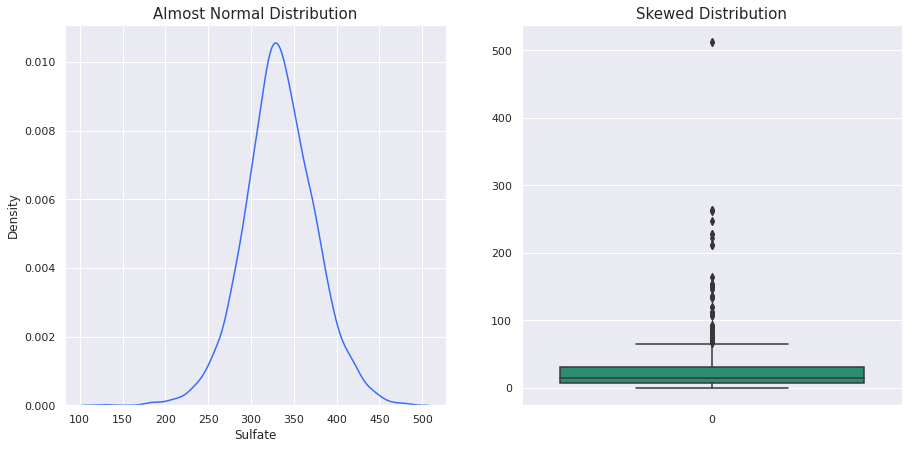

In [3]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plt.title("Almost Normal Distribution", fontsize=15)
sns.kdeplot(data = df_normal["Sulfate"])
plt.subplot(1,2,2)
plt.title("Skewed Distribution", fontsize=15)
sns.boxplot(data = df_skew["Fare"], palette="Dark2")
plt.show()

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#5CCBD0;
           font-size:20px;
           font-family:Nexa;
           letter-spacing:0.5px">
        <p style="padding: 10px;
              color:black;">
            <b>How to Handle Outliers?</b>
        </p>
</div>

<img src=https://cdn.discordapp.com/attachments/517815672613503006/874185466637877318/unknown.png>

<div class="alert alert-block alert-info" style="font-size:14px; font-family:nexa">
    <b>1. Trimming</b> is the method of cutting off or getting rid of the outliers at the end of the dataset. This is easier than all the other methods. <br>
    <b>2. Capping</b> is setting a limit for the feature and set the value of all the outliers exceeding the limit to the value of the limit. So in the student example, we will set a limit of score and change the score of the 2% student to that. For example, 75 is the max score limit that we set. The score of 2% outlier students will be set to 75. <br>
    <b>3. Percentile</b> method is equal percentile on both the sides to detect outliers. Once you detect these outliers you can use either trimming or capping to get rid of them.
</div>

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#7C5099;
           font-size:20px;
           font-family:Nexa;
           letter-spacing:0.5px">
        <p style="padding: 10px;
              color:white;">
            <b>1. Trimming & Standard Deviation</b>
        </p>
</div>

In [4]:
#defining lower and upper limit
norm_upper_limit = df_normal["Sulfate"].mean() + 3 * df_normal["Sulfate"].std()
norm_lower_limit = df_normal["Sulfate"].mean() - 3 * df_normal["Sulfate"].std()

In [5]:
#trimming the outliers away and we only have the distribution in 3 standard deviation
df_normal_new = df_normal[(df_normal["Sulfate"] > norm_lower_limit) & (df_normal["Sulfate"] < norm_upper_limit)]

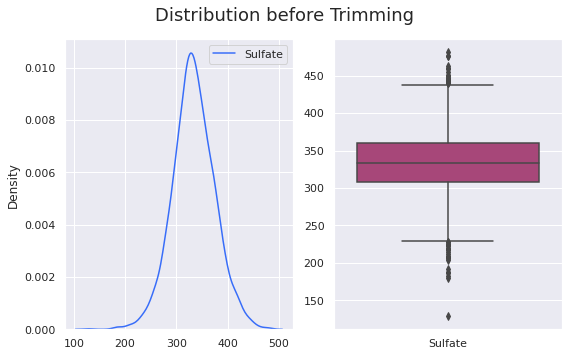

In [6]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution before Trimming", fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df_normal)
plt.subplot(1,2,2)
sns.boxplot(data = df_normal, palette="magma")
plt.tight_layout()
plt.show()

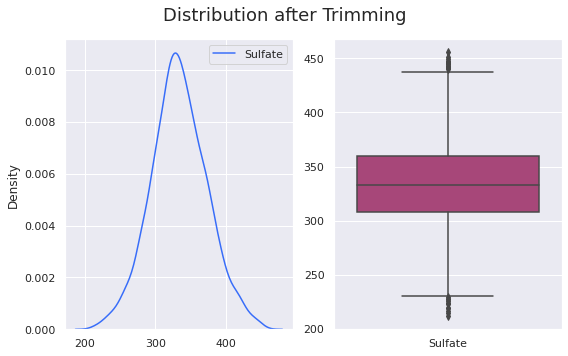

In [7]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution after Trimming",fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df_normal_new)
plt.subplot(1,2,2)
sns.boxplot(data = df_normal_new, palette="magma")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info" style="font-size:14px; font-family:nexa">
    See how the distribution did not get effected in this method. Also, we got rid of the outliers. One bad thing about this method is loss of information. We got rid of corresponding feature information which might have been useful in some way for the model. However, just like dropping nun values, this method might result to loss of information.
</div>

***

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#2AB28C;
           font-size:20px;
           font-family:Nexa;
           letter-spacing:0.5px">
        <p style="padding: 10px;
              color:white;">
            <b>2. Capping & Inter-Quartile Range (IQR)</b>
        </p>
</div>

In [8]:
#finding the Q1(25 percentile) and Q3(75 percentile)
q1 = df_skew["Fare"].quantile(0.25)
q2 = df_skew["Fare"].quantile(0.75)

In [9]:
#finding out the value of Inter Quartile Range
IQR = q2 - q1

In [10]:
#defining max and min limits
max_limit = q2 + (1.5 * IQR)
min_limit = q1 - (1.5 * IQR) 

In [11]:
#capping
df_skew_new = pd.DataFrame(np.where(df_skew["Fare"] > max_limit, max_limit, 
         (np.where(df_skew["Fare"] < min_limit, min_limit, df_skew["Fare"]))), columns=["Fare"])

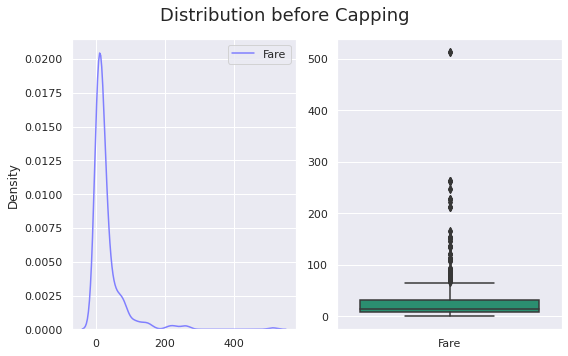

In [12]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution before Capping", fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df_skew, palette="cool")
plt.subplot(1,2,2)
sns.boxplot(data = df_skew, palette="Dark2")
plt.tight_layout()
plt.show()

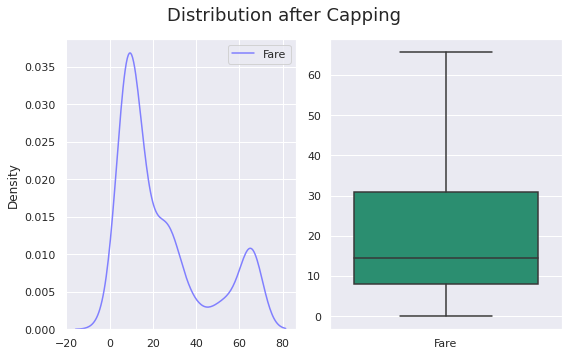

In [13]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution after Capping",fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df_skew_new, palette="cool")
plt.subplot(1,2,2)
sns.boxplot(data = df_skew_new, palette="Dark2")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info" style="font-size:14px; font-family:nexa">
    Notice how we got rid of the outliers. Also, as the outlier values were replaced by the max and min limit, notice, how in the PDF or KDEplot, there is a buldge or more values near 60-80. 
</div>

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#FD7056;
           font-size:20px;
           font-family:Nexa;
           letter-spacing:0.5px">
        <p style="padding: 10px;
              color:white;">
            <b>3. Percentile Method</b>
        </p>
</div>
<div class="alert alert-block alert-info" style="font-size:14px; font-family:nexa">
    In percentile method, you decide a specific threshold in percentile. So, use the same function that I have used for q1 and q2 in finding out IQR. Use that to decide a certain threshold, say for example, aynthing above 98 percentile and below 2 percentile will be considered as an outlier. Then you can go ahead and use trimming or capping to handle them. I have showed both the ways in the above examples. <br>
    Percentile method is arbitrary and you will have to find out a value manually and here domain knowledge will help you a lot. Domain knowledge is the strongest pillar in feature engineering. If you do not know about the data, start googling and learning more about it. Learn more about the features and you will develop a basic intuition and you might find a custom way to handle outliers. Experiment, do trial and error and have fun with ML. Keep kaggling! 
</div>

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#FF0861;
           font-size:20px;
           font-family:Nexa;
           letter-spacing:0.5px">
        <p style="padding: 10px;
              color:white;">
            <b>If you have found the notebook useful, please upvote it so that more people finds it! :)</b>
        </p>
</div>